<div style="font-size: 30px; font-weight: bold;">
    список VISA
</div>

In [ ]:
import pyvisa
rm = pyvisa.ResourceManager()
print(rm.list_resources())

In [ ]:
! pip install pyvisa


In [ ]:
!pip install pyvisa-py

<div style="font-size: 30px; font-weight: bold;">
    список COM-port
</div>

In [ ]:
# список COM-port
import serial
import serial.tools.list_ports
import time

print("Доступные порты:")
for port in serial.tools.list_ports.comports():
    print(f"  {port.device}: {port.description}")

<div style="font-size: 30px; font-weight: bold;">
    Подключение мощемера (pm400)
</div>

In [ ]:
# Подключение мощемера (pm400)
from devices.pm_400.PMDevice import PMDevicePM100D, measure_average_power
pm_device=PMDevicePM100D()



In [ ]:
current_pm_power = measure_average_power(pm_device=pm_device,duration=1,aver_point=3)
print(f'Current pm power = {current_pm_power}mW')

In [ ]:
# Отключить соединение
pm_device.disconnect()

<div style="font-size: 30px; font-weight: bold;">
    Подключение источника напряжения UT3005
</div>

In [ ]:
# Подключение источника напряжения UT3005
from devices.ut_3005.VoltageDriverUT3005 import VoltageDriverUT3005
ut=VoltageDriverUT3005('COM8')
ut.turn_on()
voltage=0
ut.set_voltage(voltage)

In [ ]:
voltage=0.3237
ut.set_voltage(voltage)

In [ ]:
# Oтключить OUT и закрыть COM-порт.
# ut.out_off_and_close_COM()

<div style="font-size: 30px; font-weight: bold;">
    Подключение РЧ анализатора
</div>

In [ ]:
#Подключение РЧ анализатора
import matplotlib.pyplot as plt
f_start=9e+3
f_stop=6.2e+9
f_center=(f_start + f_stop) / 2

from devices.rsa_device.RF306B import RF306B 
rf_device=RF306B()
rf_device.set_cf(f_center)
frequencies, powers=rf_device.get_rf()
frequencies, powers=frequencies[3:], powers[3:]
plt.plot(frequencies, powers)
plt.figure(figsize=(16, 9))
plt.show()
print(len(powers))

<div style="font-size: 30px; font-weight: bold;">
    Подключение тока накачки ПОУ (cld1015)
</div>

In [1]:
# Подключение драйвера тока лазерного диода (cld1015)
from devices.cdl_1015.CLD1015 import CLD1015
LD = CLD1015()
LD.turn_on_all()

CLD1015 inited!
CLD1015: Tec is ON
CLD1015: laser is ON


In [103]:
current=200
LD.set_current(current) 

CLD1015: Set laser current 200mA


In [ ]:
LD.turn_off_all() # отключение

<div style="font-size: 30px; font-weight: bold;">
    Подключение линии задержки
</div>

In [3]:
#Подключение линии задержки
from devices.odl_650.OpticDelayLine_new import OpticDelayLine
odl = OpticDelayLine('COM10')
# Инициализация
odl.initialize()
# Прочитать текущее время
current_delay = odl.get_time_delay()

ODL: порт COM10 открыт
Отправлено: T?
Получено: T?
Получено: TIME:0.000
Получено: Done
Текущая задержка: 0.0


In [71]:
delay=200
odl.set_time_delay(delay)

Установка задержки: 200
Отправлено: T200
Получено: T200
Ответ не 'Done'. Попытка 1 из 10
Пауза 3.0 сек перед повторной отправкой...
Отправлено: T200
Получено: T200
Получено: Done
Задержка установлена успешно (попытка 2)


True

In [75]:
for delay in range(0, 300, 10):
    odl.set_time_delay(delay)

Установка задержки: 0
Отправлено: T0
Получено: T0
Ответ не 'Done'. Попытка 1 из 10
Пауза 3.0 сек перед повторной отправкой...
Отправлено: T0
Получено: T0
Ответ не 'Done'. Попытка 2 из 10
Пауза 3.0 сек перед повторной отправкой...
Отправлено: T0
Получено: T0
Ответ не 'Done'. Попытка 3 из 10
Пауза 3.0 сек перед повторной отправкой...
Отправлено: T0
Получено: T0
Ответ не 'Done'. Попытка 4 из 10
Пауза 3.0 сек перед повторной отправкой...
Отправлено: T0
Получено: T0
Получено: Done
Задержка установлена успешно (попытка 5)
Установка задержки: 10
Отправлено: T10
Получено: T10
Получено: Done
Задержка установлена успешно (попытка 1)
Установка задержки: 20
Отправлено: T20
Получено: T20
Получено: Done
Задержка установлена успешно (попытка 1)
Установка задержки: 30
Отправлено: T30
Получено: T30


KeyboardInterrupt: 

In [ ]:
# Закрыть соединение 
odl.disconnect()

<div style="font-size: 30px; font-weight: bold;">
    Подключение к фильтру (BTF100)
</div>

In [ ]:
# Подключение к BTF100
from devices.btf_100.btf_100 import BTF100
COM_PORT = 'COM11'
btf = BTF100(port=COM_PORT)

In [ ]:
print("Получение текущих параметров")
wl, bw = btf.get_wavelength()
if wl is not None:
    print(f"get_wavelength(): WL={wl:.2f} нм, BW={bw:.2f} нм")
else:
    print("get_wavelength() - ОШИБКА")

In [ ]:
test_wl=1550
btf.set_wavelength(test_wl)
wl, bw = btf.get_wavelength()
print(f"Текущие параметры: WL={wl:.2f} нм, BW={bw:.2f} нм")

In [ ]:
test_bw=1
btf.set_linewidth(test_bw)
wl, bw = btf.get_wavelength()
print(f"Текущие параметры: WL={wl:.2f} нм, BW={bw:.2f} нм")

In [ ]:
# Закрыть соединение 
# btf.disconnect()

<div style="font-size: 30px; font-weight: bold;">
    Yokogawa
</div>

In [83]:
# импорт библиотеки и создание объекта
from devices.yokogawa.Yokogawa_OSA import YokogawaOSA
osa = YokogawaOSA(write_TR='A')
# osa.set_start(1400)
# osa.set_stop(1600)
# osa.close_connect()
# osa.set_resolution(0.02)
# osa.set_lin_scale()

VisaIOError: VI_ERROR_RSRC_NFOUND (-1073807343): Insufficient location information or the requested device or resource is not present in the system.

In [85]:
osa.set_start(1400)
osa.set_stop(1600)
osa.set_resolution(0.02)

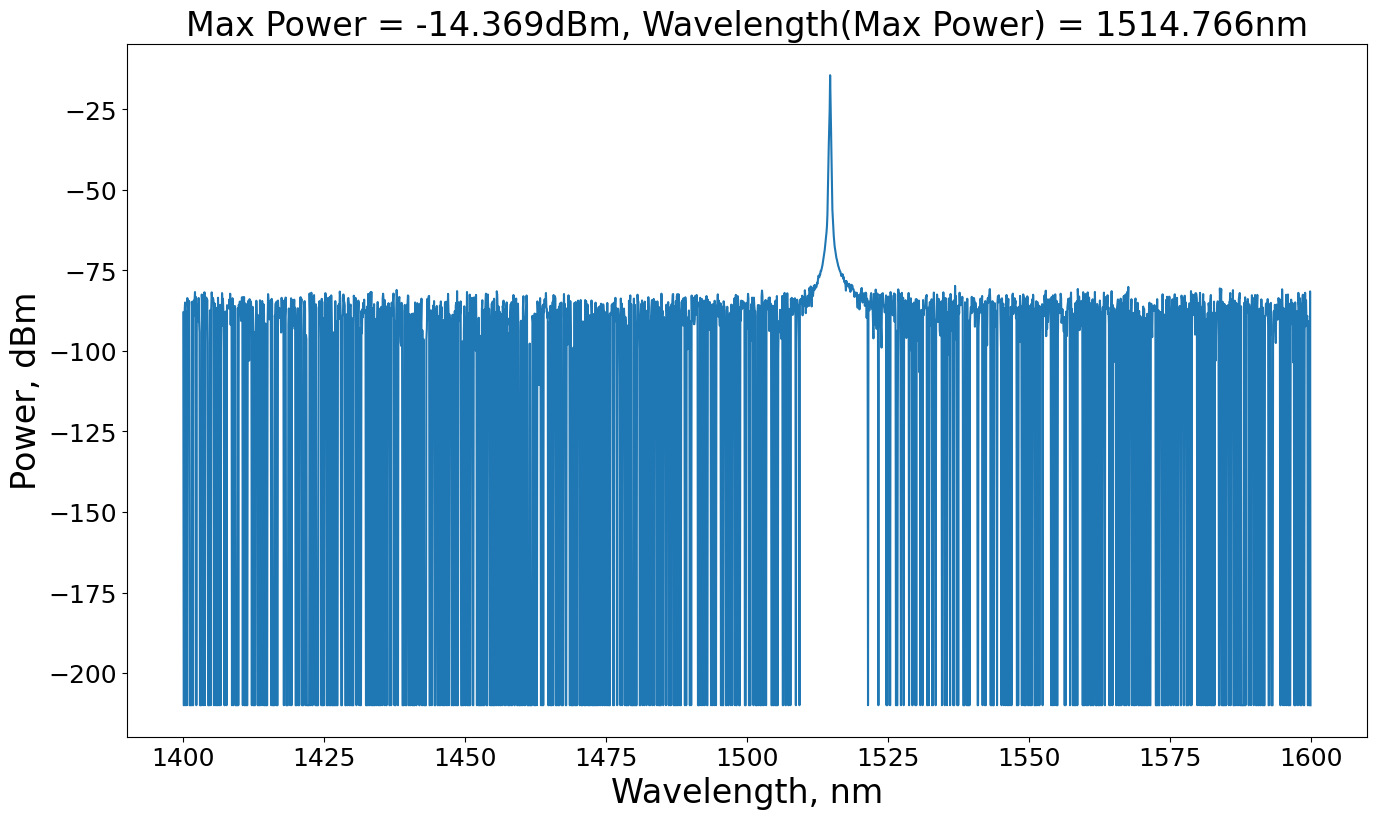

In [89]:
import matplotlib.pyplot as plt
import datetime
import numpy as np
time_suffix = datetime.datetime.now().strftime("%B-%d-%Y_time_%H-%M-%S")
png_path=f'optical_spectrum_tunable_filter_{time_suffix}.png'
wave_arr, pow_arr = osa.get_os()
plt.figure(figsize=(16, 9))
plt.plot(wave_arr, pow_arr)
plt.xlabel('Wavelength, nm', fontsize=24)
plt.ylabel('Power, dBm', fontsize=24)
plt.tick_params(axis='both', labelsize=18)
max_index = np.argmax(pow_arr)
peak_power = float(pow_arr[max_index])
peak_wave = float(wave_arr[max_index])
plt.title(f'Max Power = {peak_power:.3f}dBm, Wavelength(Max Power) = {peak_wave:.3f}nm',fontsize=24)
plt.savefig(png_path, dpi=300, bbox_inches='tight')

In [ ]:
osa.close_connect()

<div style="font-size: 30px; font-weight: bold;">
    Осциллограф
</div>
        

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from devices.oscilloscope.tektronix_DPO71604C import Oscilloscope
osciloscope_IP = "10.2.60.150"
osciloscope_PORT = 4000
osciloscope_CHANNEL = 4 

# Подключение
osc = Oscilloscope(osciloscope_IP, osciloscope_PORT)

In [ ]:
# закрыть соединение
osc.disconnect()

In [ ]:
time,voltage =osc.get_oscilloscope_data(channel=4)
time_ns=time*1e+9
plt.plot(time_ns,voltage)
plt.xlabel('Time, ns')
plt.ylabel('Voltage, V')
plt.show()
print(f"Длина списка time = {len(time)}")

In [ ]:
# Измерение со статистикой
stats = osc.measure_freq_stats(4)
print(f"\nСтатистика частоты:")
print(f"  Текущее: {stats['value_GHz']:.3f} ГГц")
print(f"  Среднее: {stats['mean_GHz']:.3f} ГГц")
print(f"  Мин: {stats['min_GHz']:.3f} ГГц")
print(f"  Макс: {stats['max_GHz']:.3f} ГГц")
print(f"  Стд.отклонение: {stats['std_GHz']:.3f} ГГц")
print(f"  Количество: {stats['count']}")

In [ ]:
# Управление состоянием захвата сигнала
# osc.acquire_state('run')
# osc.acquire_state('stop')

In [ ]:
osc.set_triger_50()



In [ ]:
osc.duration_time(duration=5e-9)

In [ ]:
from measure_libs.yokogawa_measure_lib import yoko_measurement
from devices.yokogawa.Yokogawa_OSA import YokogawaOSA
from devices.cdl_1015.CLD1015 import CLD1015
from devices.btf_100.btf_100 import BTF100
from scripts.create_folder import create_date_folder 
yoko=YokogawaOSA()




In [ ]:
yoko_measurement(
                device=yoko, 
                save_folder_path=r'C:\Users\nsuln\Documents\Laser_with_BTF', 
                filename='', 
                folder_structure='lin_bicolor_laser_PM_coupler_test_B21043779_port1-port4',
            save_png=True)
